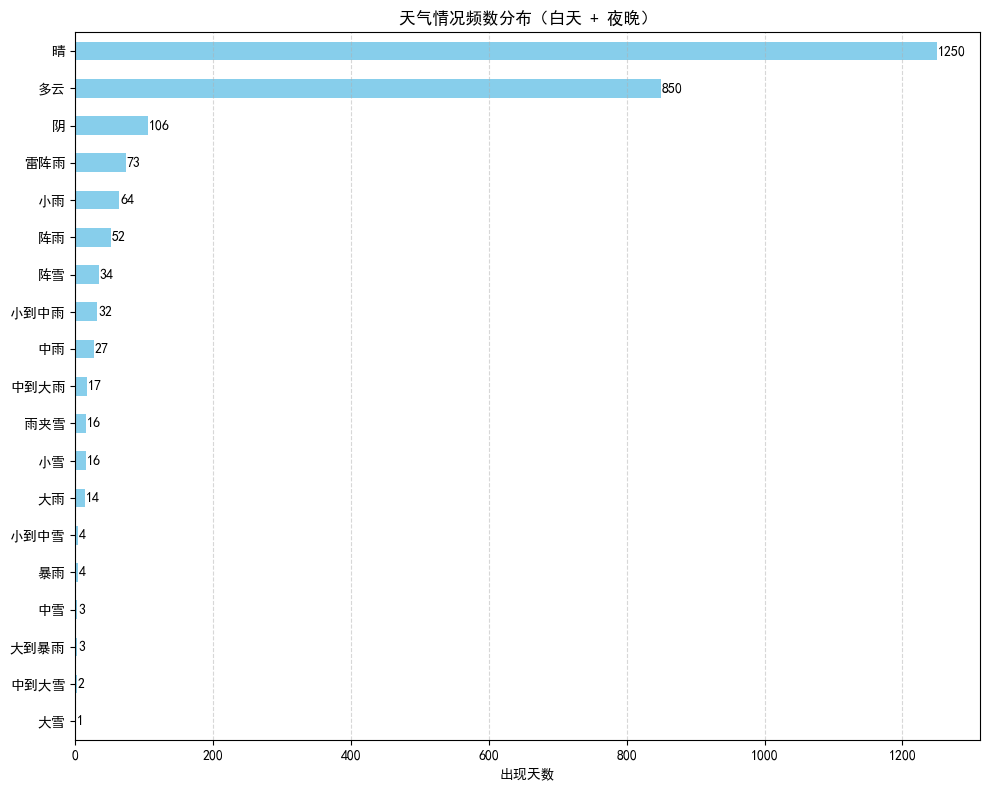

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

dalian_weather = pd.read_csv("cleaned_weather.csv")
dalian_weather[['weather_day', 'weather_night']] = dalian_weather['weather'].str.split('/', expand=True)

for col in ['weather_day', 'weather_night']:
    dalian_weather[col] = dalian_weather[col].str.strip()
    dalian_weather[col] = dalian_weather[col].str.replace('\u3000', '', regex=True)
    dalian_weather[col] = dalian_weather[col].str.replace(' ', '', regex=True)

weather_freq = weather_freq.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
ax = weather_freq.plot(kind='barh', color='skyblue')

for i, v in enumerate(weather_freq):
    ax.text(v + 1, i, str(int(v)), va='center', fontsize=10)

plt.xlabel('出现天数')
plt.title('天气情况频数分布（白天 + 夜晚）')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [12]:
dalian_weather["date"] = pd.to_datetime(dalian_weather["date"], format="%Y年%m月%d日", errors="coerce")

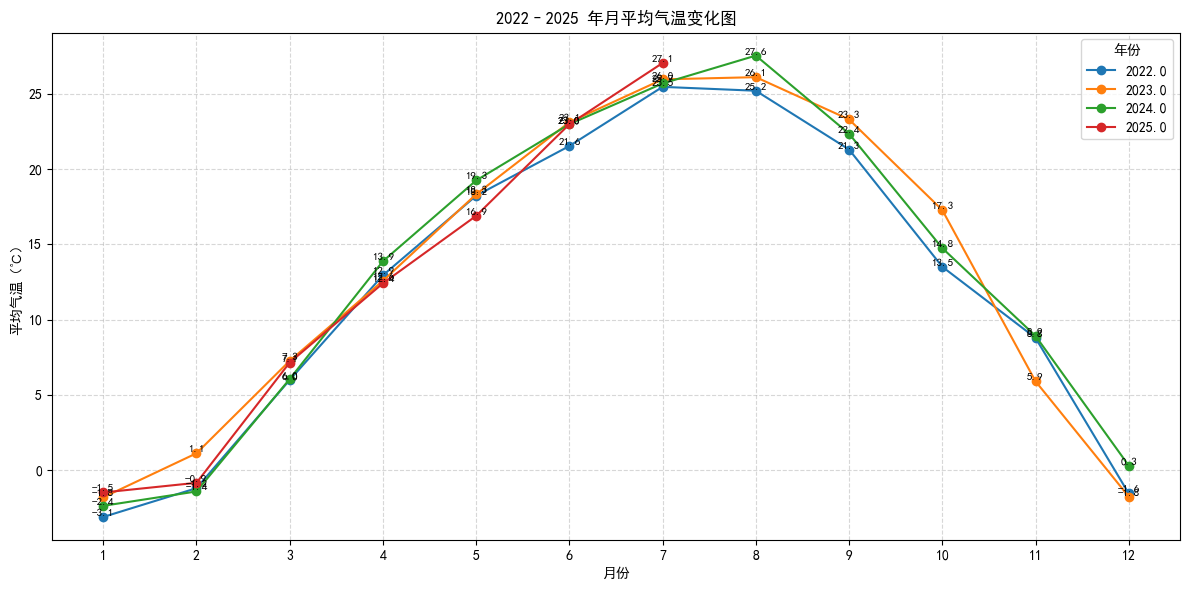

In [13]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

dalian_weather['temp_avg'] = (dalian_weather['temp_low'] + dalian_weather['temp_high']) / 2

mask = dalian_weather['date'].dt.year.between(2022, 2025)
monthly = (dalian_weather.loc[mask]
           .groupby([dalian_weather['date'].dt.year,
                     dalian_weather['date'].dt.month])['temp_avg']
           .mean()
           .unstack(0)
           .sort_index())

ax = monthly.plot(marker='o', figsize=(12, 6))
for col in monthly.columns:
    for x, y in enumerate(monthly[col]):
        ax.text(x + 1, y, f'{y:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_title('2022–2025 年月平均气温变化图')
ax.set_xlabel('月份')
ax.set_ylabel('平均气温（℃）')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xticks(range(1, 13))
ax.legend(title='年份')
plt.tight_layout()
plt.show()

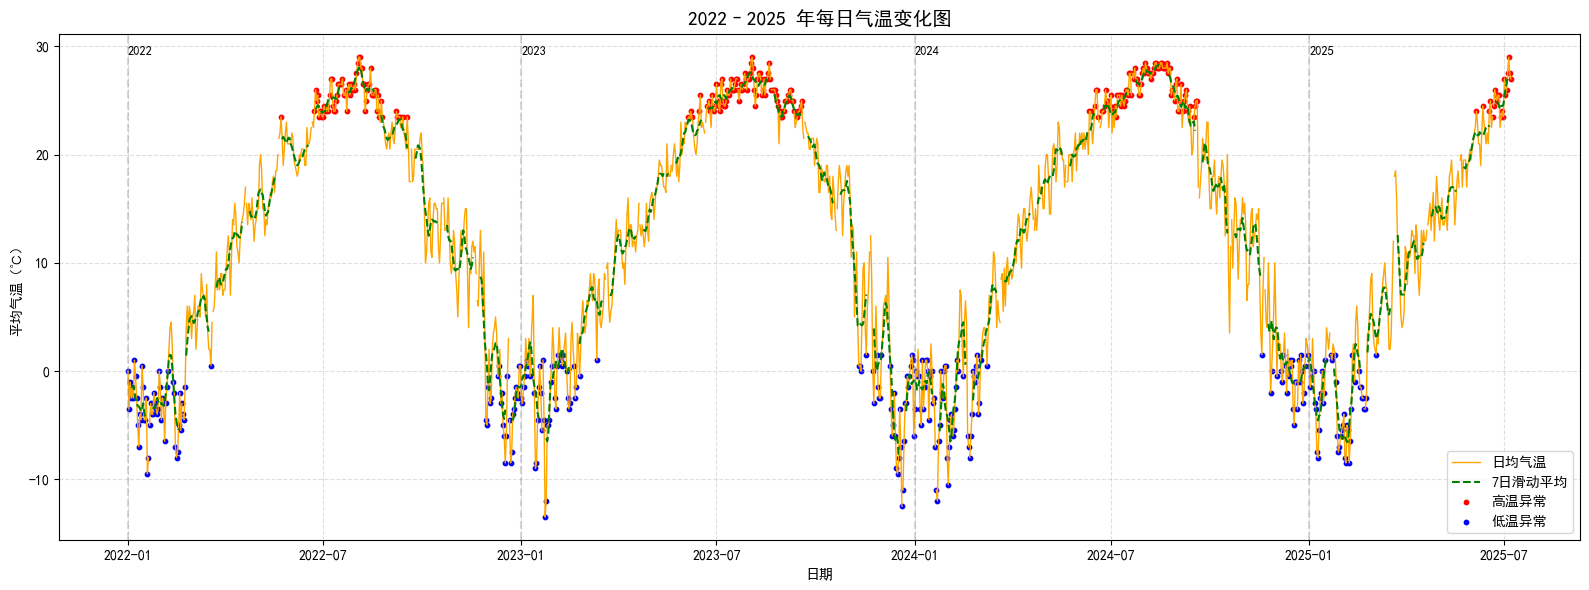

In [15]:
dalian_weather['temp_smooth'] = dalian_weather['temp_avg'].rolling(window=7, center=True).mean()

threshold_high = dalian_weather['temp_avg'].mean() + dalian_weather['temp_avg'].std()
threshold_low = dalian_weather['temp_avg'].mean() - dalian_weather['temp_avg'].std()

plt.figure(figsize=(16, 6))
plt.plot(dalian_weather['date'], dalian_weather['temp_avg'], color='orange', linewidth=1, label='日均气温')
plt.plot(dalian_weather['date'], dalian_weather['temp_smooth'], color='green', linestyle='--', label='7日滑动平均')

plt.scatter(dalian_weather['date'][dalian_weather['temp_avg'] > threshold_high], dalian_weather['temp_avg'][dalian_weather['temp_avg'] > threshold_high],
            color='red', s=10, label='高温异常')
plt.scatter(dalian_weather['date'][dalian_weather['temp_avg'] < threshold_low], dalian_weather['temp_avg'][dalian_weather['temp_avg'] < threshold_low],
            color='blue', s=10, label='低温异常')

for year in range(2022, 2026):
    start = dalian_weather[dalian_weather['date'].dt.year == year]['date'].min()
    plt.axvline(start, linestyle='--', color='gray', alpha=0.3)
    plt.text(start, dalian_weather['temp_avg'].max(), str(year), ha='left', va='bottom', fontsize=9)

plt.title("2022–2025 年每日气温变化图", fontsize=14)
plt.xlabel("日期")
plt.ylabel("平均气温（℃）")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
dalian_weather.head()

,Unnamed: 0,date,weather,temp,wind,year,month,wind_day,wind_night,wind_day_level,wind_night_level,temp_high,temp_low,weather_day,weather_night,temp_avg,temp_smooth
0,0,2022-01-01,多云 / 多云,7℃/-7℃,北风 5-6级 / 北风 5-6级,2022.0,1.0,北风 5-6级,北风 5-6级,5-6,5-6,7.0,-7.0,多云,多云,0.0,NaN
1,1,2022-01-02,晴 / 多云,0℃/-7℃,北风 3-4级 / 北风 3-4级,2022.0,1.0,北风 3-4级,北风 3-4级,3-4,3-4,0.0,-7.0,晴,多云,-3.5,NaN
2,2,2022-01-03,多云 / 晴,4℃/-6℃,西风 4-5级 / 西风 4-5级,2022.0,1.0,西风 4-5级,西风 4-5级,4-5,4-5,4.0,-6.0,多云,晴,-1.0,NaN
3,3,2022-01-04,晴 / 多云,0℃/-5℃,东北风 3-4级 / 东北风 3-4级,2022.0,1.0,东北风 3-4级,东北风 3-4级,3-4,3-4,0.0,-5.0,晴,多云,-2.5,-1.428571
4,4,2022-01-05,多云 / 晴,1℃/-4℃,西风 4-5级 / 西风 4-5级,2022.0,1.0,西风 4-5级,西风 4-5级,4-5,4-5,1.0,-4.0,多云,晴,-1.5,-1.500000


<Figure size 1200x600 with 0 Axes>

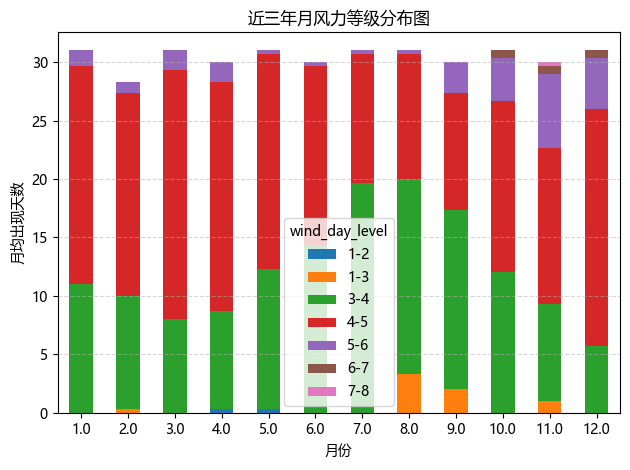

<Figure size 1200x600 with 0 Axes>

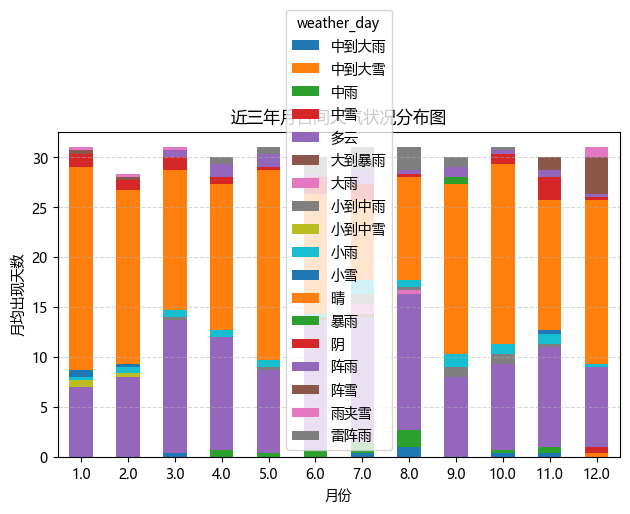

<Figure size 1200x600 with 0 Axes>

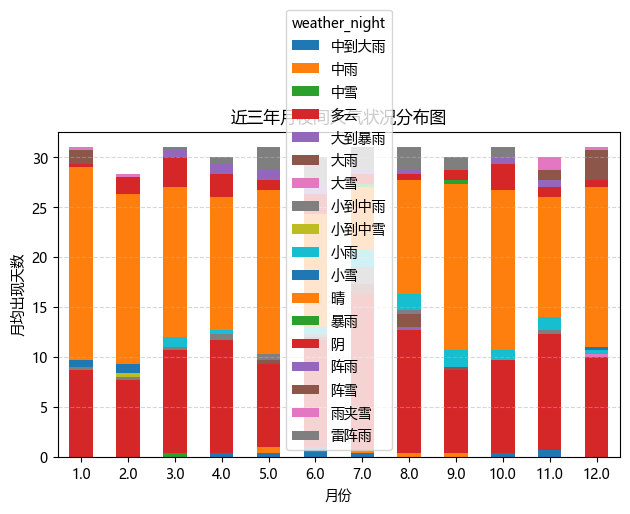

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

dalian_weather['date'] = pd.to_datetime(dalian_weather['date'], errors='coerce')
dalian_weather['year'] = dalian_weather['date'].dt.year
dalian_weather['month'] = dalian_weather['date'].dt.month

dalian_weather_recent = dalian_weather[dalian_weather['year'].between(2022, 2024)].copy()

wind_monthly = (
    dalian_weather_recent.groupby(['month', 'wind_day_level']).size()
    .unstack(fill_value=0)
    .div(3)
)

plt.figure(figsize=(12, 6))
wind_monthly.plot(kind='bar', stacked=True)
plt.title('近三年月风力等级分布图')
plt.xlabel('月份')
plt.ylabel('月均出现天数')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

weather_monthly_day = (
    dalian_weather_recent.groupby(['month', 'weather_day']).size()
    .unstack(fill_value=0)
    .div(3)
)

plt.figure(figsize=(12, 6))
weather_monthly_day.plot(kind='bar', stacked=True)
plt.title('近三年月日间天气状况分布图')
plt.xlabel('月份')
plt.ylabel('月均出现天数')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

weather_monthly_night = (
    dalian_weather_recent.groupby(['month', 'weather_night']).size()
    .unstack(fill_value=0)
    .div(3)
)

plt.figure(figsize=(12, 6))
weather_monthly_night.plot(kind='bar', stacked=True)
plt.title('近三年月夜间天气状况分布图')
plt.xlabel('月份')
plt.ylabel('月均出现天数')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()